In [619]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler, PowerTransformer, LabelEncoder
from sklearn.linear_model import LinearRegression


In [620]:
db = pd.read_csv("data/train.csv")
db.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [621]:
db["SalePrice"].max()

755000

In [622]:
info = db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# Creating Functions for managing various custom operations in this notebook

## Creating a function for identifying numerical and categorical columns to better manage features

In [623]:
def automate_colms(cols):
    cata_cols = []
    num_cols = []
    for i in cols:
        if db[i].dtype == "object" or db[i].dtype == "category":
            cata_cols.append(i)
        elif db[i].dtype in ["int64", "float64", "int32", "float32"]:
             if i not in ['Id', 'SalePrice']:
                num_cols.append(i)
        else:
            cata_cols.append(i)
    return cata_cols, num_cols

# Handling Null Values

## Identifying null columns

In [624]:
def print_null(db):
    drop_cols = []
    null_cols = []
    for i in db.columns:
        if db[i].isna().sum() > 0:
            percentage = round((db[i].isna().sum()/db[i].count())* 100, 2)
            if percentage >= 10:
                drop_cols.append(i)
                print(f"{i}: {percentage}")
            else:
                null_cols.append(i)
                print(f"{i}: {percentage}")
    return drop_cols, null_cols

drop_cols, null_cols = print_null(db)

LotFrontage: 21.57
Alley: 1504.4
MasVnrType: 148.3
MasVnrArea: 0.55
BsmtQual: 2.6
BsmtCond: 2.6
BsmtExposure: 2.67
BsmtFinType1: 2.6
BsmtFinType2: 2.67
Electrical: 0.07
FireplaceQu: 89.61
GarageType: 5.87
GarageYrBlt: 5.87
GarageFinish: 5.87
GarageQual: 5.87
GarageCond: 5.87
PoolQC: 20757.14
Fence: 419.57
MiscFeature: 2603.7


## Dropping features which have null values more than 10% of total feature values

In [625]:
db = db.drop(columns=drop_cols, axis=1)

## Printing rest columns with null values 

In [626]:
drop_cols, null_cols = print_null(db)

MasVnrArea: 0.55
BsmtQual: 2.6
BsmtCond: 2.6
BsmtExposure: 2.67
BsmtFinType1: 2.6
BsmtFinType2: 2.67
Electrical: 0.07
GarageType: 5.87
GarageYrBlt: 5.87
GarageFinish: 5.87
GarageQual: 5.87
GarageCond: 5.87


## Identifying the type of features with null values ie: numerical or categorical

In [627]:
null_cata, null_num = automate_colms(null_cols)
print(f"Null Catagorical Columns: {null_cata}, Null Numerical Columns: {null_num}")

Null Catagorical Columns: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'], Null Numerical Columns: ['MasVnrArea', 'GarageYrBlt']


## Imputing the values to handle null values for both categorical and numerical null columns

In [628]:
for i in null_cata:
    db[i].fillna(db[i].mode()[0], inplace = True)

for i in null_num:
    db[i].fillna(db[i].median(), inplace = True)

C:\Users\apoor\AppData\Local\Temp\ipykernel_15400\3223594109.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db[i].fillna(db[i].mode()[0], inplace = True)
C:\Users\apoor\AppData\Local\Temp\ipykernel_15400\3223594109.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

## Checking the updated columns

In [629]:
db.head()

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


## Basemodel using Linear Regression

In [630]:
numerical_columns = db.select_dtypes(include=[np.number]).columns
numerical_columns = numerical_columns[1:-1]
categorical_columns = db.select_dtypes(include=["object"]).columns

### Encoding categorical features using One Hot Encoding

In [631]:

x = db.iloc[:,1:-1]
# x.columns = x.columns.astype(str)
y = db.iloc[:,-1]

x = pd.get_dummies(x, columns=categorical_columns, drop_first=True)


In [632]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

score = np.sqrt(mean_squared_error(y_test,y_pred))

print(f"Root Mean Squared Error for basemodel: {round(score,2)}")

Root Mean Squared Error for basemodel: 46685.57


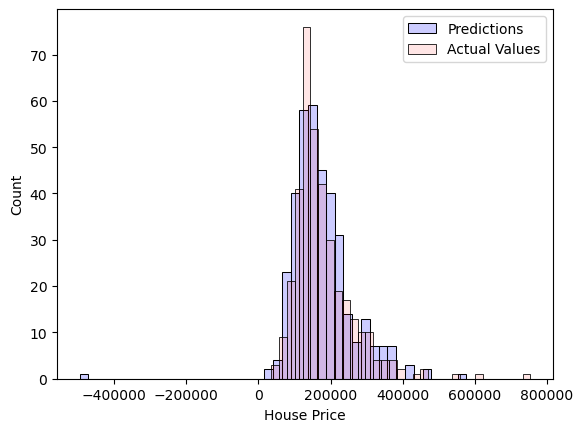

In [633]:
plt.Figure()
sns.histplot(y_pred, color='blue', alpha = 0.2, label = "Predictions")
sns.histplot(y_test, color='red', alpha = 0.1, label = "Actual Values")
plt.xlabel("House Price")
plt.legend()
plt.show()

In [634]:
print(y_pred)

[ 154418.22899554  352627.89431045   91083.43866933  179398.23489208
  325287.82901723   65194.0563119   229658.8662507   145195.67156899
   54681.91344939  145092.58204248  146632.32486779  100845.79577609
   76492.82496827  220321.0842267   174446.78628764  129460.6072431
  189241.66222401  132451.16475356  128876.107052    217568.10614904
  160858.40817491  208873.34165101  169350.98449173  126995.74021525
  200723.05955431  134727.76785421  195398.6537118   103856.80335024
  175382.60780229  206203.58855628  157893.43817678  277007.88917373
  243427.24921757  110359.68091574  235416.91008872  150553.34999169
  139659.84989296  202032.47045349  312124.9503846   104600.98661439
  120779.77039401  224707.38598166  100115.46948079  371297.36845419
  134357.55943259  142902.06402842   98192.6245141   136668.31594618
  423232.65406382  132217.28551693  118851.50406453  271978.0228681
  103884.44039752  293389.68280031  160528.04375225  247774.38373959
  197001.9356102   168307.84462865  

# Applying various normalization and standardization techniques to identify which technique performs best for Linear Regression

## Identifying numerical and categorical columns

In [635]:
cata_cols , num_cols = automate_colms(db.columns)

print(cata_cols)
print(num_cols)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [636]:
normal_models = {}

x = db.iloc[:, 1:-1]
x.columns = x.columns.astype(str)
y = db.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42)

x_num = x_train[num_cols]
x_num_test = x_test[num_cols]
x_cata = x_train[cata_cols]

In [637]:
x_num.columns

Index(['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')

In [638]:


standard = StandardScaler()
minMax = MinMaxScaler()
robust = RobustScaler()
maxabs = MaxAbsScaler()
power = PowerTransformer()

normal_models["StandardScaler"] = pd.DataFrame(standard.fit_transform(x_num), columns = x_num.columns)
normal_models["MinMaxScaler"] = pd.DataFrame(minMax.fit_transform(x_num), columns = x_num.columns)
normal_models["RobustScaler"] = pd.DataFrame(robust.fit_transform(x_num), columns = x_num.columns)
normal_models["MaxAbsoluteScaler"] = pd.DataFrame(maxabs.fit_transform(x_num), columns = x_num.columns)
normal_models["PowerTransformer"] = pd.DataFrame(power.fit_transform(x_num), columns = x_num.columns)

# normalized_dataset = {key : pd.concat([value, x_cata.reset_index(drop=True)], axis=1) for key, value in normal_models.items()}

c:\Users\apoor\anaconda3\Lib\site-packages\numpy\_core\_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


In [639]:
scores = {}
for key, value in normal_models.items():
    lr = LinearRegression()
    value.columns = value.columns.astype(str)
    lr.fit(value,y_train)
    
    y_pred = lr.predict(x_num_test)
    score = mean_squared_error(y_test,y_pred)
    scores[key] = score
    print(f"Mean Squared Error for {key}: {score}")


Mean Squared Error for StandardScaler: 1.2075477943152008e+16
Mean Squared Error for MinMaxScaler: 2.0077199784388116e+18
Mean Squared Error for RobustScaler: 1.1508523648869938e+16
Mean Squared Error for MaxAbsoluteScaler: 3.362692221829643e+18
Mean Squared Error for PowerTransformer: 2.3956317624250616e+16


In [640]:
print(y_pred)

[1.28977466e+08 1.97162644e+08 1.24769092e+08 1.08978902e+08
 1.80795094e+08 5.66504854e+07 2.03157583e+08 7.99867110e+07
 6.00635825e+07 1.96419282e+08 1.12473479e+08 1.33635362e+08
 1.91728695e+08 1.47881608e+08 1.31728880e+08 1.31202027e+08
 1.33755066e+08 1.17399544e+08 1.18826563e+08 1.60018664e+08
 1.80693374e+08 1.35439457e+08 1.32456957e+08 1.00669347e+08
 1.40072508e+08 1.22428449e+08 1.33677161e+08 2.07003446e+08
 1.52824811e+08 9.34461962e+07 1.14602966e+08 1.66941340e+08
 2.54559582e+08 1.21748556e+08 1.76950351e+08 1.39079444e+08
 1.33295953e+08 1.37982455e+08 2.13324421e+08 1.50482710e+08
 1.04477527e+08 1.54329700e+08 1.35129899e+08 1.76948991e+08
 1.38841496e+08 1.59223279e+08 1.17365697e+08 1.20196042e+08
 2.03772248e+08 1.59592499e+08 1.14703862e+08 1.59545791e+08
 7.57647221e+07 2.34641348e+08 8.86751516e+07 1.77207485e+08
 1.48546447e+08 1.90327945e+08 1.20295070e+08 1.02888223e+08
 9.03591026e+07 1.24824199e+08 1.59954279e+08 1.83651363e+08
 1.96833173e+08 1.854547